# introduction to quantum audio
Article : [Quantum Representations of Sound: from
mechanical waves to quantum circuits](https://arxiv.org/pdf/2301.01595)


#  Multichannel Sinngle Qubit Probability Amplitude Modulations: MSQPAM

$$ |A_{MSQPAM}\rangle = \frac{1}{\sqrt{NC}}\sum_{i=0}^{N-1}\sum_{j=0}^{C-1} |c_j\rangle\otimes\text{cos}(\theta_i|0\rangle + \text{sin}(\theta_i|1\rangle)\otimes|i\rangle$$

The Multichannel Sinngle Qubit Probability Amplitude Modulations is a derived version of SQPAM applied for multichannel.


The time register use $N$ qubits, the amplitudes register use $1$ qubits, and $C$ qubit for the channel. 

## Preparation

Relation between $a_i$ and $\alpha_i$: 
- Step 1: Add 1 to all amplitudes $a_n$
- Step 2: divide the amplitudes by 2.
- Step 3: take the square root
- Step 4: Evaluate the Inverse Sine of the result (The Inverse Cosine is also applicable, as long as the same convention is followed throughout the implementation)

$$ \theta_i = \text{sin}^{-1}\Bigl(\sqrt{\frac{a_i+1}{2}}\Bigl) $$

The mapped array of angles will enable the preparation of the MSQPAM quantum audio
state. The angles values are added by channel per each time value as MQSM.

In [84]:
# importation of the modules
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RYGate
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [83]:
# Functions 

# generation of the binary list depending of the number of qubits
def generate_binary_list_from_nqubits(n_qubits):
    """
    Generates binary strings in ascending numerical order.
    Example for 2 qubits: [‘00’, ‘01’, ‘10’, ‘11’]
    Input: 
        - n_qubits(Int) : number of qubits
    Output:
        - list of 2**n_qubits binary ascendant
    """
    return [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]

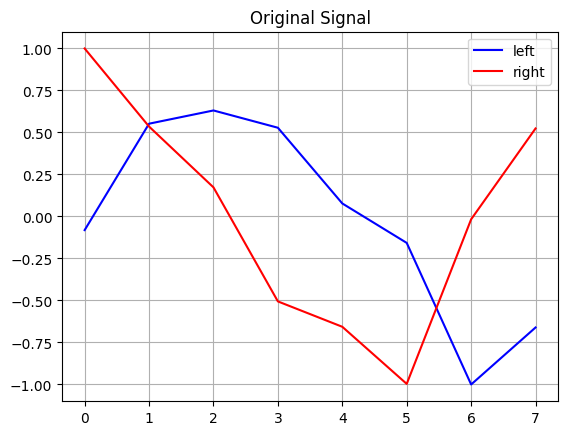

In [85]:
# Creation of an audio signal, in this example, we consider that the audio is stereo, so we have 2 channels (Left/Right)

# Resolution
AmpQubits = 4   # better resolution with an high number of amplitude qubits 
TimeQubits = 3
ChannelQubits = 1

# time vector
temp = np.arange(0,2**TimeQubits, 1)/2**TimeQubits

# Creation of a signal 
signal1 = np.sin(2*np.pi*temp)+0.2*np.random.randn(2**TimeQubits) # sinus wave + random data
signal1/=np.max(np.abs(signal1)) # normalization

signal2 = np.cos(2*np.pi*temp)+0.2*np.random.randn(2**TimeQubits) # sinus wave + random data
signal2/=np.max(np.abs(signal2)) # normalization

# Get the angle of each samples 
theta1 = np.asin(np.sqrt((signal1.astype(np.float64)+1)/2))
theta2 = np.asin(np.sqrt((signal2.astype(np.float64)+1)/2))


# Plot the signal and the quantized signal 
plt.plot(signal1, color='blue', label="left")
plt.plot(signal2, color='red', label="right")
plt.title("Original Signal")
plt.ylim([-1.1, 1.1])
plt.grid(True)
plt.legend()

plt.show()

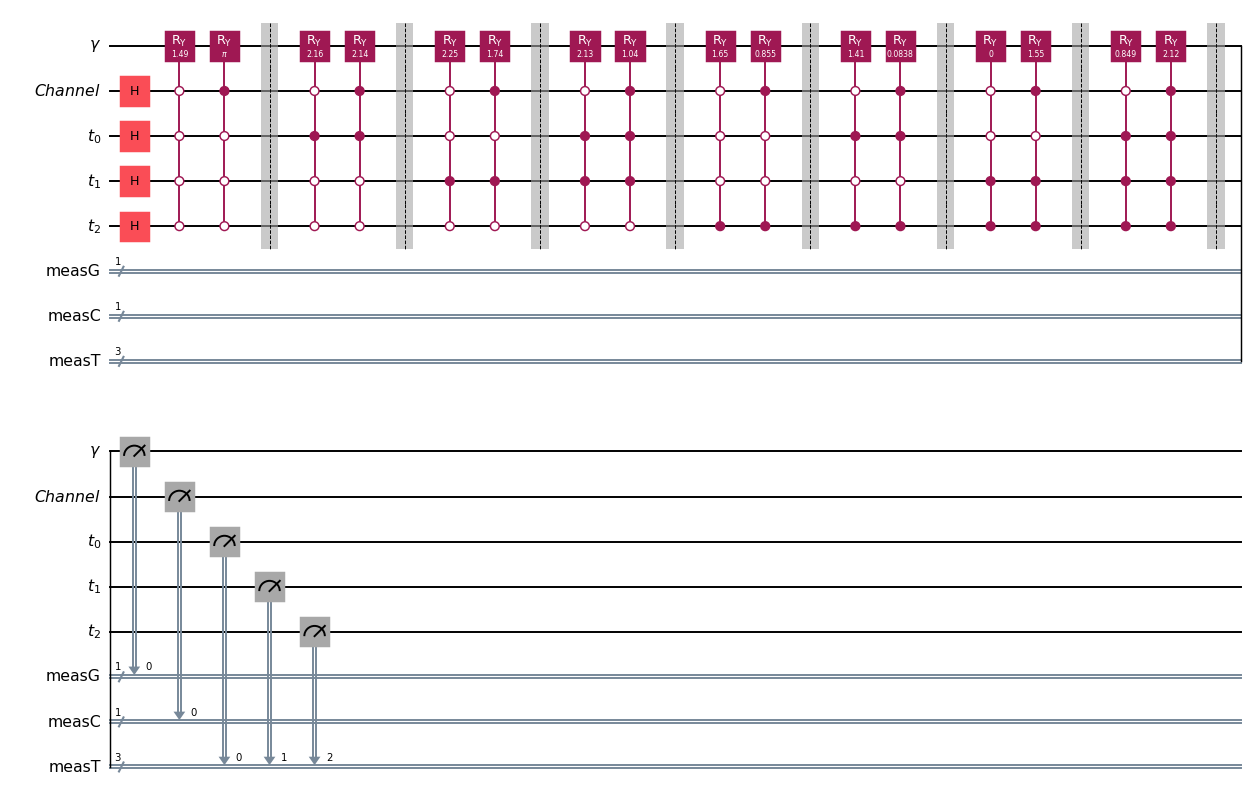

In [96]:
# Quantum register
AmpQ = QuantumRegister(1, r"\gamma") # amplitude qubit
ChannelQ = QuantumRegister(1, "Channel")
timeQ = QuantumRegister(TimeQubits, "t")

# Classical register
measG = ClassicalRegister(1         , "measG") 
measC = ClassicalRegister(1         , "measC") 
measT = ClassicalRegister(TimeQubits, "measT") 

# initalization
circuit = QuantumCircuit(AmpQ, ChannelQ, timeQ, measG, measC, measT)
circuit.h(ChannelQ)
circuit.h(timeQ)

# generation of the binary time value 
TimeBinaryList =generate_binary_list_from_nqubits(TimeQubits)

# Add Ry gates depending the binary value of channel, and time
for indexTimeBin, timebinary in enumerate(TimeBinaryList):
    # find null index in the binary string
    indices_zeros= [i+2 for i, bit in enumerate(reversed(timebinary)) if bit == '0']

    for ch_idx, theta_val in enumerate([theta1, theta2]):
        # establish the control state depending the index of the channel and binary time value.
        ctrl_complet = str(ch_idx) + timebinary
    
        # apply Ry controled gate
        cry_gate = RYGate(2*theta_val[indexTimeBin]).control(TimeQubits + 1, ctrl_state=ctrl_complet) #/!\ the angle to apply is twice in qiskit
        circuit.append(cry_gate, list(timeQ)+list(ChannelQ)+list(AmpQ))
        
    circuit.barrier()


# measure
circuit.measure(AmpQ, measG)
circuit.measure(ChannelQ, measC)
circuit.measure(timeQ, measT)
display(circuit.draw(output="mpl", scale = 0.7))

### Preparation
To get a better resolution, increase the number of shot

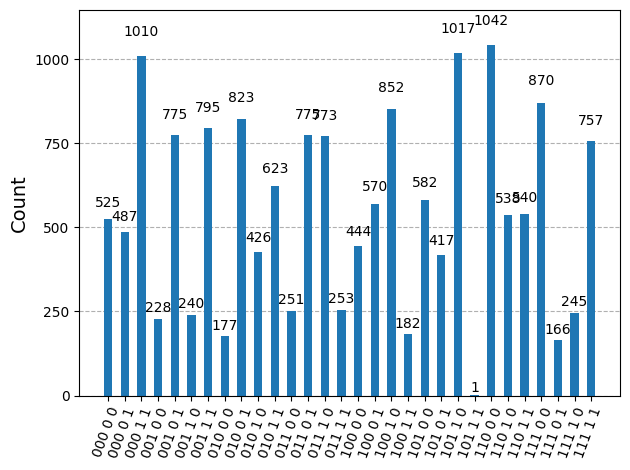

In [97]:
# run on backend then plot the histogramm
simulator = AerSimulator()
decompose_circuit = transpile(circuit, simulator)
stats = simulator.run(decompose_circuit, shots = 16*1024).result()
counts = stats.get_counts()
display(plot_histogram(counts))

## Retrieval the signal 
The way to recovert the signal is according the time measured values, the data are rearranged to get the amplitudes value. Then the signal is reconstructed. 
To het a better resolution of the signal in amplitude, the system required more qubit $a$.

In [98]:
# rearranged data by 
data_points = []
for full_bin, count in counts.items():
    # Separation of the amplitudes , channel and time register
    time_bin, channel_bin, amp_bin = full_bin.split(' ') 
    
    # Conversion binary -> int
    time_int = int(time_bin, 2)
    channel_int = int(channel_bin, 2)
    amp_int = int(amp_bin, 2)
    
    data_points.append({
        'time': time_int,
        'channel': channel_int,
        'amp': amp_int,
        'count': count
    })

# Sort by ascending time
data_points.sort(key=lambda x: x['time'])
signal_reconstruit = np.zeros((2, 2**TimeQubits, 2)) #(channel, time, amplitude)

for point in data_points:
    t = point['time']
    c = point['channel'] # value is equal to 0 or 1
    a = point['amp']
    count_val = point['count']
    signal_reconstruit[c, t, a] = count_val


# Reconstruction of the signals (left/right)
countLeft  = signal_reconstruit[0]
left       = (2*countLeft[:,1])/(countLeft[:,0]+countLeft[:,1])-1

countRight = signal_reconstruit[1]
right      = (2*countRight[:,1])/(countRight[:,0]+countRight[:,1])-1

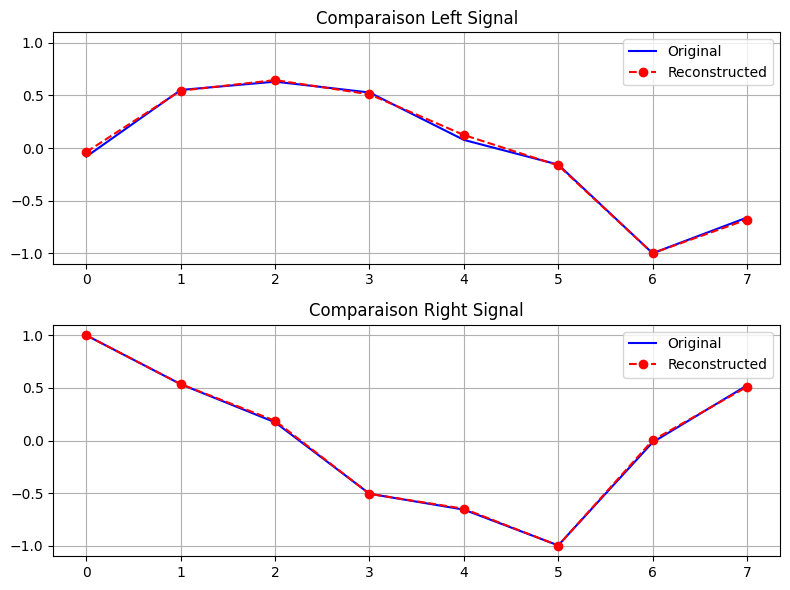

In [99]:
# Plot

fig, axs = plt.subplots(2, 1, figsize=(8, 6))
axs[0].plot(signal1, color='blue', label="Original")
axs[0].plot(left, color='red', marker='o', linestyle='--', label="Reconstructed")
axs[0].set_title("Comparaison Left Signal")
axs[0].set_ylim([-1.1, 1.1])
axs[0].legend()
axs[0].grid(True)

axs[1].plot(signal2, color='blue', label="Original")
axs[1].plot(right, color='red', marker='o', linestyle='--', label="Reconstructed")
axs[1].set_title("Comparaison Right Signal")
axs[1].grid(True)
axs[1].set_ylim([-1.1, 1.1])
axs[1].legend()
plt.tight_layout()
plt.show()

To get a better resolution of the retrieval signal, the number of shots must be high. The error between the two signals is reduced when the number of shots increase.